# 09_聚类算法-K-均值聚类

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文给大家带来的是K-均值聚类，K-means Clustering \~

今天的内容非常详细，想要完全理解 K-means 算法的同学，一定耐心看完。

先来简单说说K-均值聚类是什么吧。

**K-均值聚类** 主要用于将数据分成几个组（称为簇）。它的名字里有个“K”，就是你要提前告诉算法你想把数据分成几组。

下面举一个通俗易懂的例子，很容易可以理解\~

1. **假设有一堆数据点**：比如说，你有一群学生，你想根据他们的身高和体重把他们分成几组。
2. **选择K个初始中心点**：假设你想把学生分成3组（K=3），你可以先随机选出3个学生的身高和体重，作为初始的“中心点”。
3. **计算距离**：然后，你把每个学生的身高体重和这3个中心点的身高体重进行比较，看哪个中心点离这个学生最近。比如，A学生离中心点1最近，就把A学生分到组1里。
4. **重新计算中心点**：当所有学生都分好组后，每个组都有了一批学生。接下来，你需要重新计算每个组的中心点，比如，组1的新中心点就是组1里所有学生身高和体重的平均值。
5. **重复步骤3和4**：再用新的中心点重新分组，再重新计算中心点，如此循环，直到每个组的学生基本上不再变动。

**目的**：K-均值聚类的目的是让同一组的学生（数据点）在身高体重（特征）上尽量相似，不同组之间的学生在身高体重上尽量不同。

优点很明显，理解起来简单易懂，计算起来速度快。而且对大部分常见的分组问题效果不错。

有些缺点可以容忍，需要提前指定K值（组数）。对于初始中心点的选择敏感，有时候结果不太稳定。最致命的，如果数据本身有明显的噪声或者异常点，效果可能不太好。

总之，K-均值聚类是一种把数据分组的方法，它通过找到每组数据的中心点，并不断调整这些中心点的位置，来达到分组的目的。

## 理论基础

### 数学原理与公式推理

#### 1. 目标函数

K-均值聚类的目标是最小化每个簇内样本到簇中心的距离之和。用数学符号表示，即最小化以下目标函数：


$$
J = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2
$$


其中：

- $k$是簇的数量。
- $C_i$是第 $i$个簇的样本集合。
- $x$是样本点。
- $\mu_i$是第 $i$个簇的中心（质心）。

#### 2. 质心的计算

质心是簇内所有点的平均值。第 $i$个簇的质心 $\mu_i$ 的计算公式为：


$$
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
$$


其中 $|C_i|$ 是簇 $C_i$ 中的样本点数量。

### 算法流程

1. **初始化**：随机选择 $k$个初始质心 $\mu_1, \mu_2, \ldots, \mu_k$。
2. **分配样本到最近的质心**：
3. 对每个样本点 $x$，计算其到每个质心 $\mu_i$ 的距离：


$$
d(x, \mu_i) = \| x - \mu_i \|
$$


1. 将 $x$分配到最近的质心所对应的簇 $C_i$：  
$C_i = \{ x : \| x - \mu_i \| \leq \| x - \mu_j \| \, \forall j, 1 \leq j \leq k \}$
2. **更新质心**：
3. 对每个簇 $C_i$，重新计算其质心：  
$\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$
4. **检查收敛条件**：
5. 如果质心的位置在前后两次迭代中没有显著变化，或者达到预设的迭代次数，则算法终止。
6. 否则，返回步骤2。

### 详细推导

1. **目标函数的推导**：  
目标函数 $J$表示簇内平方误差总和（Sum of Squared Errors, SSE），即所有样本点到其所属簇质心的欧几里得距离的平方和：  
$J = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2$
2. 为了最小化 $J$，我们需要反复调整每个簇的质心位置 $\mu_i$ 并重新分配样本点到簇。
3. **质心计算的推导**：
4. 对于每个簇 $C_i$，质心 $\mu_i$ 是簇内所有点的平均值：  
$\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$
5. 这是因为质心是使得簇内点到质心距离平方和最小的点。
6. **迭代更新**：
7. 在每次迭代中，通过最小化每个簇的内部误差来更新质心，并通过最小化样本点到质心的距离重新分配样本点。  
反复进行质心更新和样本点分配，直到收敛。

### 收敛性与复杂度分析

- **收敛性**：K-均值算法通过每次迭代减少目标函数 $J$的值，最终收敛到一个局部最优解。虽然不能保证找到全局最优解，但通常通过多次运行K-均值并选择最小的 $J$值的结果来提高效果。
- **复杂度**：在每次迭代中，计算每个样本点到每个质心的距离的复杂度是 $O(nk)$，更新质心的复杂度是 $O(n)$，因此总的时间复杂度大致为 $O(tnk)$，其中 $t$是迭代次数，$n$是样本数量，$k$是簇的数量。

综上，K-均值聚类通过迭代优化，逐步最小化样本点到质心的距离平方和，达到将数据分成多个相似簇的目的。

## 完整案例

我们来进行一个完整的K-均值聚类实际案例示例。

使用经典的**鸢尾花数据集（Iris Dataset）**，这个数据集包含150个样本，每个样本有4个特征：花萼长度、花萼宽度、花瓣长度和花瓣宽度。此外，每个样本还标注了其所属的花的品种（鸢尾花的三种品种：Iris-setosa、Iris-versicolor和Iris-virginica）。

完整代码，大家可以根据注释进行理解，后面可以使用自己的数据集进行实现，加强理解。

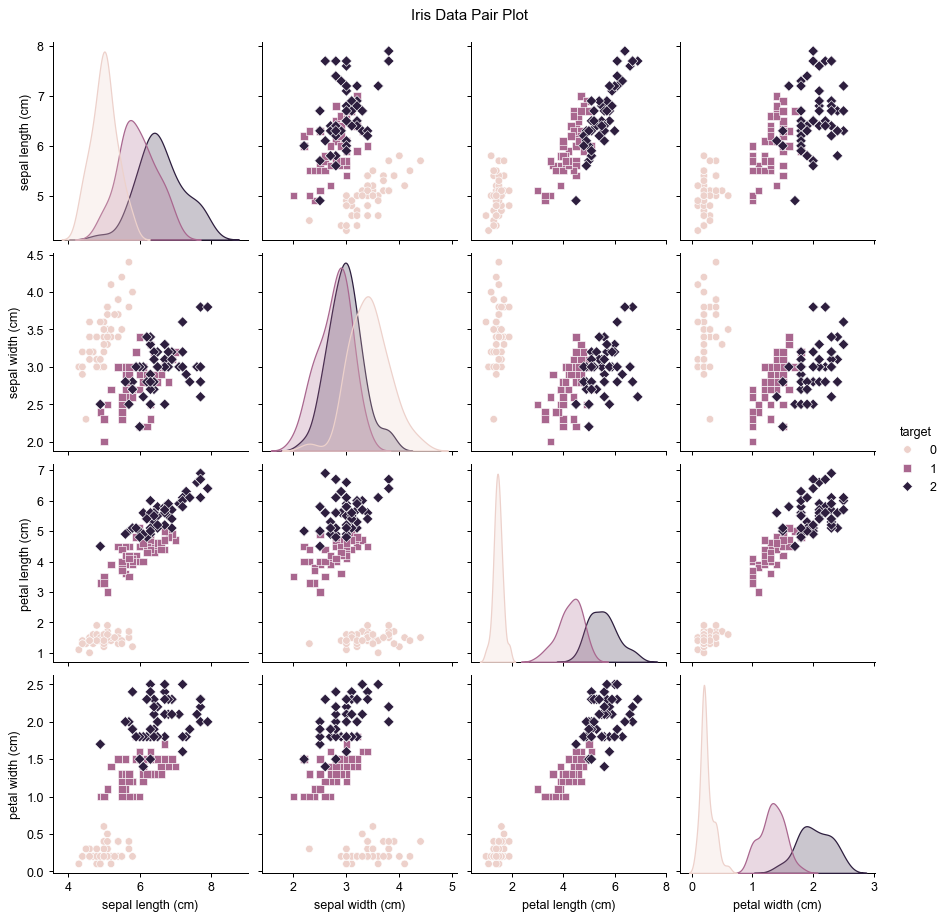

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 加载数据集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 将数据集转换为DataFrame，便于处理
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# 数据可视化
sns.pairplot(df, hue='target', markers=["o", "s", "D"])
plt.suptitle('Iris Data Pair Plot', y=1.02)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_022.png)

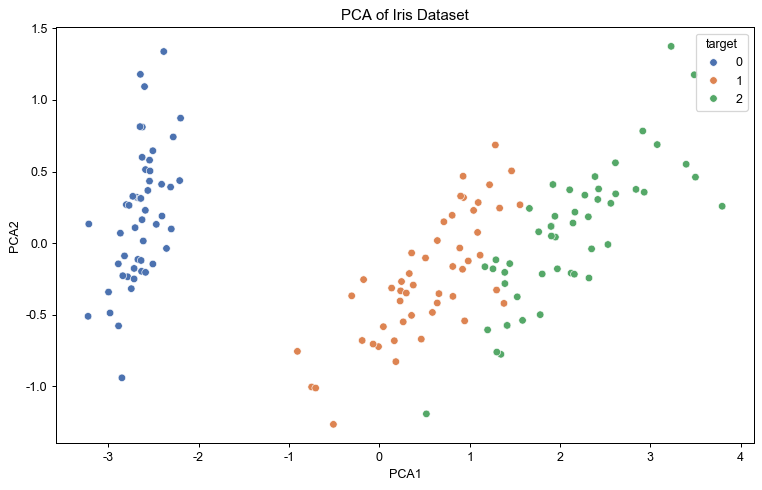

In [3]:
# 使用PCA进行降维到2D，以便于可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['target'] = y

# 可视化降维后的数据
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='target', data=df_pca, palette='deep', markers=["o", "s", "D"])
plt.title('PCA of Iris Dataset')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_023.png)

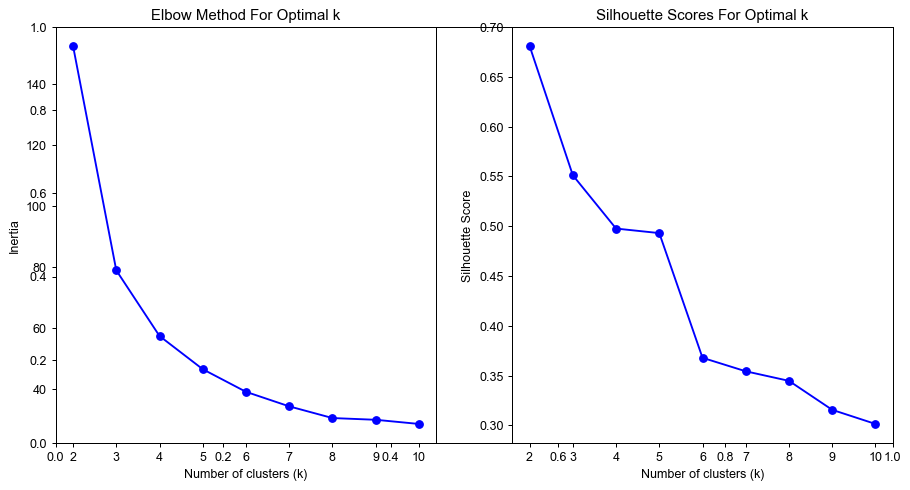

In [4]:
# 确定最优的簇数
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

# 绘制肘部法图和轮廓系数图
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores For Optimal k')

plt.show()

![原文参考图，当前结果见代码输出](attachments/img_024.png)

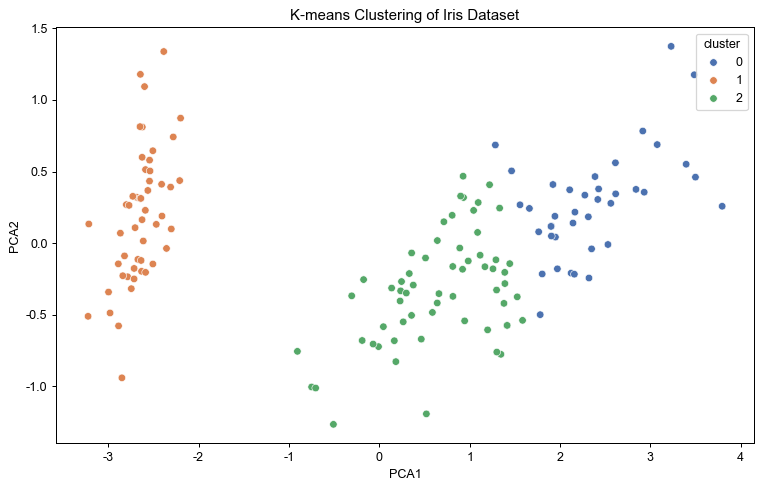

Cluster Centers (Centroids):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           6.853846          3.076923           5.715385          2.053846
1           5.006000          3.428000           1.462000          0.246000
2           5.883607          2.740984           4.388525          1.434426
Final Silhouette Score: 0.5511916046195919


In [5]:
# 选择最优簇数并进行K-均值聚类
optimal_k = 3  # 根据肘部法和轮廓系数选择
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

# 将聚类结果加入到DataFrame
df_pca['cluster'] = labels

# 可视化聚类结果
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_pca, palette='deep', markers=["o", "s", "D"])
plt.title('K-means Clustering of Iris Dataset')
plt.show()

# 打印聚类中心
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=feature_names)
print("Cluster Centers (Centroids):\n", centroids_df)

# 打印轮廓系数
final_silhouette_score = silhouette_score(X, labels)
print(f"Final Silhouette Score: {final_silhouette_score}")

其中需要注意的几个步骤：

1. **数据加载与初步处理**：

   - 加载鸢尾花数据集，并将其转换为`DataFrame`格式。
   - 使用Seaborn进行数据的初步可视化，绘制特征对特征的散点图，展示不同类别的分布情况。
2. **降维与可视化**：

   - 使用PCA将数据降维到2D，以便于后续的可视化。
   - 绘制降维后的数据分布图，进一步观察数据的结构。
3. **确定最优的簇数**：

   - 使用肘部法和轮廓系数（Silhouette Score）来确定最优的簇数。
   - 绘制肘部法图和轮廓系数图，根据图形选择最优的簇数（本例中选择k=3）。
4. **K-均值聚类**：

   - 使用K-均值算法进行聚类，并将结果标签加入到DataFrame中。
   - 可视化聚类结果，展示不同簇的分布情况。
5. **聚类中心与轮廓系数**：

   - 打印聚类中心（质心）的位置。
   - 计算并打印最终的轮廓系数，以评估聚类效果。

### 算法优化

算法优化方面，可以考虑三方面：

- 初始质心选择优化
- 数据标准化
- 重复实验

**1. 初始质心选择优化**：使用`k-means++`算法来优化初始质心的选择，从而提高聚类的稳定性和准确性。

In [6]:
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

**2. 数据标准化**：在聚类之前，对数据进行标准化处理，使得每个特征的均值为0，方差为1。

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**3. 重复实验**：运行多次K-均值聚类，并选择最小的目标函数值对应的聚类结果。

In [8]:
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)

通过整个的代码和优化策略，大家可以感受整个过程。代码中，实现了鸢尾花数据集的聚类分析，并且通过可视化、评估指标等手段对聚类效果进行了详细的评估和优化。

## 模型分析

### K-均值聚类模型的优缺点

**优点**：

1. **简单易实现**：K-均值聚类算法简单直观，易于理解和实现。
2. **计算速度快**：适用于大规模数据集，计算复杂度较低。
3. **适用范围广**：对于球状分布的数据效果较好，特别是在数据量不是很大、簇的形状规则且差异明显时表现良好。

**缺点**：

1. **需要预先指定簇的数量K**：对于不知道簇数量的数据，难以确定合适的K值。
2. **对初始质心的选择敏感**：初始质心的选择会影响最终的聚类结果，可能导致局部最优解。
3. **对异常值敏感**：异常值或噪声会对质心的计算和最终的聚类结果产生较大影响。

### 与相似算法的对比

| **对比项** | **K-均值聚类 (K-Means)** | **层次聚类 (Hierarchical Clustering)** | **密度聚类 (DBSCAN)** |
|-|-|-|-|
| **簇的数量** | 需要预先指定簇的数量 | 不需要预先指定簇的数量 | 不需要预先指定簇的数量 |
| **适用数据** | 适用于球状分布的簇，较大的数据集 | 适用于较小规模的数据集，能够处理多层次的簇结构 | 适用于任意形状的簇，能够处理噪声和异常值 |
| **计算复杂度** | 计算复杂度相对较低，适用于大数据集 | 计算复杂度较高，不适合大数据集 | 计算复杂度中等，可能较高，尤其是邻域搜索计算 |
| **簇的形状** | 适用于球状、圆形或凸形的簇 | 能处理各种形状的簇，但可能会导致较复杂的层次结构 | 能处理任意形状的簇，包括不规则簇 |
| **噪声与异常值** | 对噪声和异常值敏感，可能会影响聚类结果 | 不太受噪声影响，但对于异常值的处理较弱 | 对噪声和异常值不敏感，能够识别噪声点并将其排除 |
| **结果解释** | 结果易于理解，聚类的数量和形状清晰 | 结果易于解释，能够显示层次结构，但可能较复杂 | 聚类结果也易于理解，但对于密度阈值的选择可能需要更多的调优 |
| **参数调节** | 需要选择簇的数量和初始质心的选择 | 无需指定簇数，但需要选择合适的距离度量和链接方法 | 需要调整邻域大小（ε）和最小样本数（minPts） |
| **适用场景** | 适合大规模、均匀分布的数据集，簇的形状规则 | 适合较小规模的数据集，尤其是想要探索层次关系的情况 | 适合密度变化较大的数据集，尤其是具有噪声和异常值的数据集 |

### 优选和考虑其他算法的情况

**K-均值聚类适用情况**：

- **数据量较大**：K-均值聚类的计算速度快，适合处理大规模数据集。
- **簇的形状较为规则**：如果数据集的簇形状接近球状，K-均值聚类效果较好。
- **已知簇的数量**：当我们事先知道数据应该分成几个簇时，K-均值聚类是一个简单有效的选择。

**考虑其他算法的情况**：

- **不确定簇的数量**：如果无法确定簇的数量，可以考虑使用层次聚类或基于密度的聚类算法。
- **数据包含异常值或噪声**：对于数据中存在异常值或噪声的情况，可以考虑使用DBSCAN等密度聚类算法，这些算法对异常值较为鲁棒。
- **簇形状复杂**：如果数据集中的簇形状非常复杂或者不规则，层次聚类或者基于密度的聚类可能更适合。

综上所述，K-均值聚类是一种简单且有效的聚类算法，特别适合处理大规模数据集和具有明显球状分布的数据。在选择算法时，需要根据数据的特点（如簇的形状、数据量、簇数量的确定性等）来权衡不同算法的优缺点，以达到最佳的聚类效果。